In [ ]:
import jax
import jax.numpy as jnp
from jax import random
from jax import grad, jit, vmap
from jax import lax
from jax import value_and_grad
import optax
from tqdm import tqdm

def model(params, x):
    omega1, omega2, c, w1, w2, b1, b2 = params
    h1 = jnp.tanh(jnp.dot(x, w1) + b1)
    h2 = jnp.tanh(jnp.dot(x, w2) + b2)
    return omega1 * h1 + omega2 * h2 + c

def loss(params, x):
    y_pred = model(params, x)
    return jnp.mean((y_pred - x**2/2) ** 2)

key = random.PRNGKey(0)

keys = random.split(key, 7)
params = [random.normal(k, shape=()) for k in keys]

lr = 0.01

optimizer = optax.adam(lr)
opt_state = optimizer.init(params)
param_history = []
loss_history = []

loss_and_grad = jit(value_and_grad(loss))  
for step in tqdm(range(50_000)):
    param_history.append(params)
    key, subkey = random.split(key)
    x = random.uniform(subkey, shape=(10000,), minval=-10.0, maxval=10.0)

    current_loss, grads = loss_and_grad(params, x)
    loss_history.append(current_loss)
    
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)

100%|██████████| 50000/50000 [04:43<00:00, 176.22it/s]


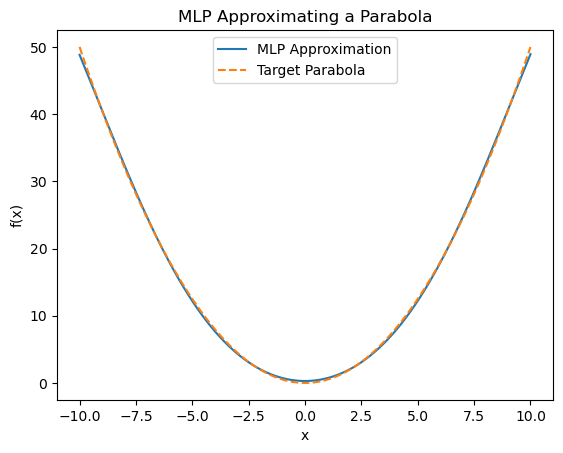

In [32]:
import matplotlib.pyplot as plt
x_test = jnp.linspace(-10, 10, 200)
y_pred = model(params, x_test)
plt.plot(x_test, y_pred, label='MLP Approximation')
plt.plot(x_test, x_test**2/2, label='Target Parabola', linestyle='dashed')
plt.legend()
plt.title("MLP Approximating a Parabola")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()


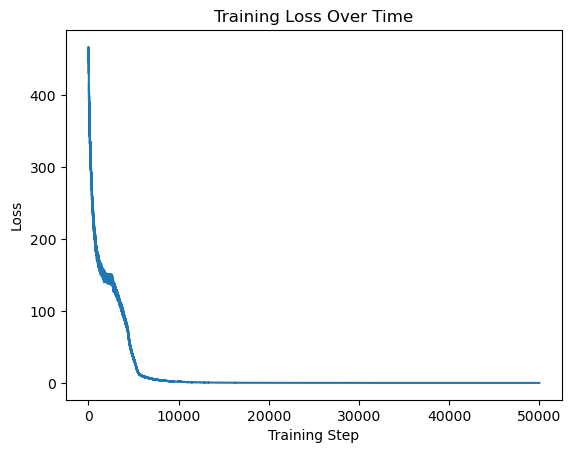

In [31]:
plt.plot(loss_history)
plt.title("Training Loss Over Time")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.show()

In [33]:
print("Final Parameters:")
print("\tomega1:", params[0])
print("\tomega2:", params[1])
print("\tc:", params[2])
print("\tw1:", params[3])
print("\tw2:", params[4])
print("\tb1:", params[5])
print("\tb2:", params[6])

Final Parameters:
	omega1: 49.48937
	omega2: -49.491844
	c: 90.680016
	w1: -0.16991779
	w2: -0.17010933
	b1: -1.5466756
	b2: 1.5466459
